# 🏥 3D DICOM Fine-Tuning for Multi-Label Pathology Classification

**Workflow:** Load preprocessed 3D volumes (.npy) → Fine-tune 3D-ResNet50 → Evaluate per-class metrics

**Prerequisites:** Run `Preprocess_DICOM_to_Volumes_3D.ipynb` first to generate volumes

## 📦 Section 1: Install Dependencies and Imports

In [57]:
import subprocess
import sys

# Install required packages
packages = ['torch', 'torchvision', 'pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn', 'tqdm']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import pandas as pd
import numpy as np
import os
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import json
from datetime import datetime

print("✅ All packages imported successfully!")
print(f"\nGPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"GPU Count: {torch.cuda.device_count()}")

Installing scikit-learn...
✅ All packages imported successfully!

GPU Available: True
GPU Device: Tesla T4
GPU Count: 1


## 🔧 Section 2: Mount Google Drive & Configure Paths

In [58]:
# Mount Google Drive
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_FOLDER = '/content/drive/MyDrive/artishow'
    print("✅ Google Drive mounted")
except ImportError:
    # Local development
    DRIVE_FOLDER = '/home/infres/ahmed-25/artishow'
    print("⚠️ Running locally (no Google Drive)")

# Configure paths
VOLUMES_CSV = os.path.join(DRIVE_FOLDER, 'dataset_labeled_volumes_3d.csv')
OUTPUT_FOLDER = os.path.join(DRIVE_FOLDER, 'dicom_volume', 'model_outputs_3d_v3')

# Create output folder
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

print(f"\n📁 Paths:")
print(f"  Volumes CSV: {VOLUMES_CSV}")
print(f"  Output folder: {OUTPUT_FOLDER}")

# Verify CSV exists
if os.path.exists(VOLUMES_CSV):
    print(f"✅ Volumes CSV found!")
else:
    print(f"❌ ERROR: Volumes CSV not found!")
    print(f"   Run Preprocess_DICOM_to_Volumes_3D.ipynb first")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted

📁 Paths:
  Volumes CSV: /content/drive/MyDrive/artishow/dataset_labeled_volumes_3d.csv
  Output folder: /content/drive/MyDrive/artishow/dicom_volume/model_outputs_3d_v3
✅ Volumes CSV found!


## 📊 Section 3: Load Preprocessed Volumes Index & Labels

In [59]:
# Load preprocessed volumes index
df_labels = pd.read_csv(VOLUMES_CSV)

print(f"{'='*70}")
print("📊 PREPROCESSED VOLUMES DATASET")
print(f"{'='*70}")
print(f"Total volumes: {len(df_labels)}")
print(f"Shape: {df_labels.shape}")
print(f"\nFirst 3 rows:")
print(df_labels[['image_id', 'volume_npy_path', 'Normal']].head(3))

# Verify volumes exist
missing = sum(1 for path in df_labels['volume_npy_path'] if not os.path.exists(path))
if missing > 0:
    print(f"\n⚠️ {missing} volumes missing!")
    df_labels = df_labels[df_labels['volume_npy_path'].apply(lambda x: os.path.exists(x))]
else:
    print(f"\n✅ All {len(df_labels)} volume files verified!")

# Define pathology classes
PATHOLOGY_CLASSES = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Pneumonia', 'Pneumothorax',
    'Edema', 'Emphysema', 'Fibrosis', 'Infiltration', 'Mass', 'Nodule',
    'Hernia', 'Fracture', 'Pleural_Thickening', 'Opacity', 'Consolidation',
    'Granuloma', 'Calcinosis', 'Scoliosis', 'Atherosclerosis', 'Normal'
]

print(f"\n🏷️ Pathology classes: {len(PATHOLOGY_CLASSES)}")
label_counts = df_labels[PATHOLOGY_CLASSES].sum().sort_values(ascending=False)
for label, count in label_counts.head(5).items():
    pct = count / len(df_labels) * 100
    print(f"  {label:20s}: {int(count):4d} ({pct:5.1f}%)")

📊 PREPROCESSED VOLUMES DATASET
Total volumes: 2557
Shape: (2557, 40)

First 3 rows:
                   image_id  \
0  CXR3037_IM-1410-1001.png   
1  CXR3037_IM-1410-2001.png   
2  CXR3499_IM-1703-2002.png   

                                     volume_npy_path  Normal  
0  /content/drive/MyDrive/artishow/dicom_volume/v...       1  
1  /content/drive/MyDrive/artishow/dicom_volume/v...       1  
2  /content/drive/MyDrive/artishow/dicom_volume/v...       1  

✅ All 2557 volume files verified!

🏷️ Pathology classes: 21
  Normal              : 1412 ( 55.2%)
  Calcinosis          :  383 ( 15.0%)
  Opacity             :  317 ( 12.4%)
  Granuloma           :  303 ( 11.8%)
  Atelectasis         :  206 (  8.1%)


## 📦 Section 4: Helper Functions for Volume Loading

In [60]:
def load_volume_npy(volume_path):
    """
    Load preprocessed volume from .npy file.
    Volumes are already windowed, resized, and normalized!
    """
    try:
        volume = np.load(volume_path)
        return volume
    except Exception as e:
        print(f"Error loading {volume_path}: {e}")
        return None

print("✅ Volume loading function defined")
print("📌 Note: Volumes are ALREADY preprocessed (windowed, resized, normalized)")

✅ Volume loading function defined
📌 Note: Volumes are ALREADY preprocessed (windowed, resized, normalized)


## 🔀 Section 5: Create Train/Val/Test Splits

In [61]:
# === STRATIFIED SPLIT FOR MULTI-LABEL ===
# For multi-label, we stratify on the dominant class (Normal)
# to preserve class distribution across train/val/test splits

from sklearn.model_selection import train_test_split

# Add a stratification column based on the dominant class
# For multi-label, we group by the presence/absence of the dominant class
df_labels['stratify_col'] = df_labels['Normal'].astype(str)

# First split: 70% train, 30% temp (val+test)
train_df, temp_df = train_test_split(
    df_labels,
    test_size=0.3,
    random_state=42,
    stratify=df_labels['stratify_col']  # Stratify on Normal class
)

# Second split: Split temp into 50/50 (val and test)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df['stratify_col']  # Stratify on Normal class
)

# Drop the temporary stratification column
train_df = train_df.drop('stratify_col', axis=1)
val_df = val_df.drop('stratify_col', axis=1)
test_df = test_df.drop('stratify_col', axis=1)

print(f"{'='*70}")
print("🔀 STRATIFIED DATASET SPLIT (70/15/15)")
print(f"{'='*70}")
print(f"Train: {len(train_df):4d} ({len(train_df)/len(df_labels)*100:5.1f}%)")
print(f"Val:   {len(val_df):4d} ({len(val_df)/len(df_labels)*100:5.1f}%)")
print(f"Test:  {len(test_df):4d} ({len(test_df)/len(df_labels)*100:5.1f}%)")
print(f"Total: {len(train_df) + len(val_df) + len(test_df)}")

# Verify stratification: compare class distributions
print(f"\n📊 Distribution Verification (Normal class):")
print(f"  Overall dataset: {df_labels['Normal'].mean():.1%}")
print(f"  Train split:     {train_df['Normal'].mean():.1%}")
print(f"  Val split:       {val_df['Normal'].mean():.1%}")
print(f"  Test split:      {test_df['Normal'].mean():.1%}")

# Save splits
train_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_train_3d.csv'), index=False)
val_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_val_3d.csv'), index=False)
test_df.to_csv(os.path.join(OUTPUT_FOLDER, 'split_test_3d.csv'), index=False)
print(f"\n✅ Stratified splits saved")

🔀 STRATIFIED DATASET SPLIT (70/15/15)
Train: 1789 ( 70.0%)
Val:    384 ( 15.0%)
Test:   384 ( 15.0%)
Total: 2557

📊 Distribution Verification (Normal class):
  Overall dataset: 55.2%
  Train split:     55.2%
  Val split:       55.2%
  Test split:      55.2%

✅ Stratified splits saved


## 🎨 Section 6: Define 3D Augmentations & Loss Function

In [62]:
# 3D AUGMENTATIONS
class Random3DFlip(nn.Module):
    """Apply random 3D flips"""
    def __init__(self, p=0.5):
        super().__init__()
        self.p = p

    def forward(self, volume):
        if np.random.random() < self.p:
            volume = torch.flip(volume, [2])  # Flip height
        if np.random.random() < self.p:
            volume = torch.flip(volume, [3])  # Flip width
        return volume

# Training transforms (with augmentation)
train_transforms = Random3DFlip(p=0.3)

# Validation/Test transforms (no augmentation)
val_transforms = nn.Identity()

print("✅ 3D augmentations defined")
print("  Train: Random flips (30% probability)")
print("  Val/Test: No augmentation")

# ============================================
# ASYMMETRIC LOSS FOR MULTI-LABEL
# ============================================

class AsymmetricLoss(nn.Module):
    """
    Asymmetric Loss for multi-label classification with class imbalance.

    Better for imbalanced multi-label problems than BCEWithLogitsLoss:
    - Treats positive and negative samples asymmetrically
    - Applies margin-based penalty for false positives/negatives
    - Reduces sensitivity to false positives on negative samples

    Reference: Asymmetric Loss For Multi-Label Classification (Ridnik et al., 2021)
    """
    def __init__(self, gamma_neg=4, gamma_pos=1, margin=1.0):
        super().__init__()
        self.gamma_neg = gamma_neg  # Focusing parameter for negative samples
        self.gamma_pos = gamma_pos  # Focusing parameter for positive samples
        self.margin = margin        # Margin parameter

    def forward(self, logits, targets):
        """
        Args:
            logits: [batch_size, num_classes] raw predictions
            targets: [batch_size, num_classes] binary labels (0 or 1)
        """
        # Convert logits to probabilities [0, 1]
        probs = torch.sigmoid(logits)

        # Clip probabilities to avoid log(0)
        probs = torch.clamp(probs, 1e-7, 1 - 1e-7)

        # Asymmetric loss calculation
        # For positive labels (target=1): penalize under-prediction
        pos_loss = -targets * torch.pow(1.0 - probs, self.gamma_pos) * torch.log(probs)

        # For negative labels (target=0): penalize over-prediction with margin
        neg_loss = -(1.0 - targets) * torch.pow(probs, self.gamma_neg) * torch.log(1.0 - probs)

        # Combine losses
        loss = pos_loss + neg_loss

        return loss.mean()


print("\n✅ AsymmetricLoss defined")
print("   - Treats positive and negative samples differently")
print("   - Better for multi-label class imbalance")
print("   - gamma_neg=4, gamma_pos=1, margin=1.0")

✅ 3D augmentations defined
  Train: Random flips (30% probability)
  Val/Test: No augmentation

✅ AsymmetricLoss defined
   - Treats positive and negative samples differently
   - Better for multi-label class imbalance
   - gamma_neg=4, gamma_pos=1, margin=1.0


## 🏗️ Section 7: Define 3D PyTorch Dataset Class

In [63]:
class DICOM3DMultiLabelDataset(Dataset):
    """Multi-label 3D Dataset loading preprocessed .npy volumes"""

    def __init__(self, dataframe, label_columns, transform=None):
        """
        Args:
            dataframe: DataFrame with 'volume_npy_path' + label columns
            label_columns: List of 21 pathology column names
            transform: Augmentation pipeline
        """
        self.dataframe = dataframe.reset_index(drop=True)
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        volume_path = row['volume_npy_path']
        image_id = row['image_id']

        # Load preprocessed volume from .npy
        volume = load_volume_npy(volume_path)

        if volume is None:
            # Create a placeholder volume with the expected numpy shape (H, W, D)
            volume = np.zeros((128, 128, 64), dtype=np.float32)

        # Convert to tensor. Original numpy volume is assumed to be (H, W, D)
        volume_tensor = torch.from_numpy(volume).float() # Shape: (H, W, D)

        # Permute to (D, H, W) to match (T, H, W) expectation of video models
        volume_tensor = volume_tensor.permute(2, 0, 1) # Shape: (D, H, W) where D is depth/time

        # Add channel dimension: (D, H, W) -> (1, D, H, W)
        volume_tensor = volume_tensor.unsqueeze(0) # Shape: (1, D, H, W)

        # Replicate the single channel to 3 channels for R3D_18 input: (1, D, H, W) -> (3, D, H, W)
        volume_tensor = volume_tensor.repeat(3, 1, 1, 1)

        # Apply transforms (augmentation)
        if self.transform:
            volume_tensor = self.transform(volume_tensor)

        # Get labels (21 binary values)
        labels = torch.tensor(row[self.label_columns].values.astype(np.float32))

        return volume_tensor, labels, image_id

print("✅ 3D Dataset class defined")
print(f"   Input: .npy volumes (128×128×64, already normalized)")
print(f"   Output: [3,64,128,128] tensor + [21] labels")

✅ 3D Dataset class defined
   Input: .npy volumes (128×128×64, already normalized)
   Output: [3,64,128,128] tensor + [21] labels


## 8️⃣ Model Definition - 3D-ResNet18

In [64]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Load 3D-ResNet18 (Kinetics pretrained)
print("\n📥 Loading 3D-ResNet18 (Kinetics pretrained)...")
try:
    model = models.video.r3d_18(pretrained=True)
    print("✅ Successfully loaded pretrained model")
except:
    print("⚠️ Using non-pretrained model")
    model = models.video.r3d_18(pretrained=False)

# Freeze early layers
for param in model.layer1.parameters():
    param.requires_grad = False
for param in model.layer2.parameters():
    param.requires_grad = False

# Replace classifier for MULTI-LABEL (21 outputs)
num_ftrs = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_ftrs, len(PATHOLOGY_CLASSES))  # 21 outputs
)

model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model configured for MULTI-LABEL classification")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Output shape: [batch_size, {len(PATHOLOGY_CLASSES)}]")

Using device: cuda

📥 Loading 3D-ResNet18 (Kinetics pretrained)...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=R3D_18_Weights.KINETICS400_V1`. You can also use `weights=R3D_18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


✅ Successfully loaded pretrained model

✅ Model configured for MULTI-LABEL classification
Total parameters: 33,177,045
Trainable parameters: 31,176,405
Output shape: [batch_size, 21]


## 9️⃣ Create DataLoaders

In [65]:
# BATCH SIZE & WORKER THREADS
BATCH_SIZE = 4
NUM_WORKERS = 2

print(f"\n{'='*70}")
print("📊 Creating 3D DICOM DataLoaders")
print(f"{'='*70}")

# Create datasets
train_dataset = DICOM3DMultiLabelDataset(
    train_df, PATHOLOGY_CLASSES, transform=train_transforms
)
val_dataset = DICOM3DMultiLabelDataset(
    val_df, PATHOLOGY_CLASSES, transform=val_transforms
)
test_dataset = DICOM3DMultiLabelDataset(
    test_df, PATHOLOGY_CLASSES, transform=val_transforms
)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset:   {len(val_dataset)}")
print(f"Test dataset:  {len(test_dataset)}")

# Create dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"\n✅ DataLoaders created")
print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")


📊 Creating 3D DICOM DataLoaders
Train dataset: 1789
Val dataset:   384
Test dataset:  384

✅ DataLoaders created
Train batches: 448
Val batches:   96
Test batches:  96


## 🔟 Training Configuration & Optimization

In [66]:
EPOCHS = 25
LEARNING_RATE = 1e-4
PATIENCE = 5
CHECKPOINT_INTERVAL = 1 # Save checkpoint every X epochs

# Initialize AsymmetricLoss (better for multi-label imbalance)
criterion = AsymmetricLoss(
    gamma_neg=4,    # Focus more on hard negative samples
    gamma_pos=1,    # Focus less on positive samples (already easier to learn)
    margin=1.0      # Margin parameter
)

optimizer = optim.Adam(
    [p for p in model.parameters() if p.requires_grad],
    lr=LEARNING_RATE,
    weight_decay=1e-5
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

history = {'train_loss': [], 'val_loss': []}
best_val_loss = float('inf')
patience_counter = 0

print(f"{'='*70}")
print("🏋️ TRAINING CONFIGURATION (v3 UPDATED)")
print(f"{'='*70}")
print(f"Epochs: {EPOCHS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Loss function: AsymmetricLoss (Multi-label with class imbalance)")
print(f"  → Better than BCEWithLogitsLoss for imbalanced multi-label tasks")
print(f"  → gamma_neg=4 (focus on hard negatives)")
print(f"  → gamma_pos=1 (normal focus on positives)")
print(f"Device: {device}")
print(f"Checkpoint interval: {CHECKPOINT_INTERVAL} epochs")
print(f"\n📊 Data Split Strategy:")
print(f"  Type: STRATIFIED (preserves class distribution)")
print(f"  Stratification: Stratified on Normal class presence")
print(f"  Train/Val/Test: 70%/15%/15%")
print(f"  Benefit: Ensures balanced evaluation across all splits")

🏋️ TRAINING CONFIGURATION (v3 UPDATED)
Epochs: 25
Learning rate: 0.0001
Batch size: 4
Loss function: AsymmetricLoss (Multi-label with class imbalance)
  → Better than BCEWithLogitsLoss for imbalanced multi-label tasks
  → gamma_neg=4 (focus on hard negatives)
  → gamma_pos=1 (normal focus on positives)
Device: cuda
Checkpoint interval: 1 epochs

📊 Data Split Strategy:
  Type: STRATIFIED (preserves class distribution)
  Stratification: Stratified on Normal class presence
  Train/Val/Test: 70%/15%/15%
  Benefit: Ensures balanced evaluation across all splits


## 1️⃣1️⃣ Training Loop & Evaluation

In [67]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train one epoch"""
    model.train()
    total_loss = 0

    for volumes, labels, _ in tqdm(loader, desc="Training"):
        volumes = volumes.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(volumes)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    """Validate one epoch"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for volumes, labels, _ in tqdm(loader, desc="Validating"):
            volumes = volumes.to(device)
            labels = labels.to(device)

            outputs = model(volumes)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(loader)

print("✅ Training and validation functions defined")

✅ Training and validation functions defined


## 1️⃣2️⃣ Main Training Loop with Early Stopping

In [68]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train one epoch"""
    model.train()
    total_loss = 0

    for volumes, labels, _ in tqdm(loader, desc="Training"):
        volumes = volumes.to(device)
        labels = labels.to(device)

        # Forward
        outputs = model(volumes)
        loss = criterion(outputs, labels)

        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

def validate(model, loader, criterion, device):
    """Validate one epoch"""
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for volumes, labels, _ in tqdm(loader, desc="Validating"):
            volumes = volumes.to(device)
            labels = labels.to(device)

            outputs = model(volumes)
            loss = criterion(outputs, labels)
            total_loss += loss.item()

    return total_loss / len(loader)

print("✅ Training functions defined")

✅ Training functions defined


In [69]:
# Main training loop
print(f"\n{'='*70}")
print("🚀 STARTING TRAINING")
print(f"{'='*70}\n")

start_epoch = 0
# Logic to find and load the latest checkpoint
latest_checkpoint_path = None
latest_epoch = -1
for f_name in os.listdir(OUTPUT_FOLDER):
    if f_name.startswith('checkpoint_epoch_') and f_name.endswith('.pth'):
        try:
            epoch_num = int(f_name.split('_')[-1].split('.')[0])
            if epoch_num > latest_epoch:
                latest_epoch = epoch_num
                latest_checkpoint_path = os.path.join(OUTPUT_FOLDER, f_name)
        except ValueError:
            continue

if latest_checkpoint_path and os.path.exists(latest_checkpoint_path):
    print(f"🔄 Resuming training from checkpoint: {latest_checkpoint_path}")
    checkpoint = torch.load(latest_checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    best_val_loss = checkpoint['best_val_loss']
    patience_counter = checkpoint['patience_counter']
    history = checkpoint['history'] # Update history from checkpoint
    print(f"   Resumed from Epoch {checkpoint['epoch']+1}, Best Val Loss: {best_val_loss:.4f}")
else:
    print("✨ No checkpoint found, starting training from scratch.")

for epoch in range(start_epoch, EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    # Train
    train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
    history['train_loss'].append(train_loss)

    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    history['val_loss'].append(val_loss)

    # Scheduler
    scheduler.step(val_loss)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")

    # Save checkpoint periodically
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        checkpoint_path = os.path.join(OUTPUT_FOLDER, f'checkpoint_epoch_{epoch+1}.pth')
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_loss': best_val_loss,
            'patience_counter': patience_counter,
            'history': history
        }, checkpoint_path)
        print(f"🔄 Checkpoint saved for epoch {epoch+1} to {checkpoint_path}")

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, 'best_model_3d.pth'))
        print("✅ Best model saved!")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹️ Early stopping")
            break

print(f"\n{'='*70}")
print("✅ TRAINING COMPLETE")
print(f"{'='*70}")


🚀 STARTING TRAINING

🔄 Resuming training from checkpoint: /content/drive/MyDrive/artishow/dicom_volume/model_outputs_3d_v3/checkpoint_epoch_7.pth
   Resumed from Epoch 7, Best Val Loss: 0.0394

Epoch 8/25


Validating: 100%|██████████| 96/96 [00:48<00:00,  1.97it/s]


Train Loss: 0.0390
Val Loss:   0.0399
🔄 Checkpoint saved for epoch 8 to /content/drive/MyDrive/artishow/dicom_volume/model_outputs_3d_v3/checkpoint_epoch_8.pth

Epoch 9/25


Validating: 100%|██████████| 96/96 [00:48<00:00,  1.96it/s]


Train Loss: 0.0391
Val Loss:   0.0412
🔄 Checkpoint saved for epoch 9 to /content/drive/MyDrive/artishow/dicom_volume/model_outputs_3d_v3/checkpoint_epoch_9.pth

Epoch 10/25


Training:   5%|▌         | 23/448 [00:30<09:27,  1.34s/it]


KeyboardInterrupt: 

## 📊 Section 12: Training History Visualization

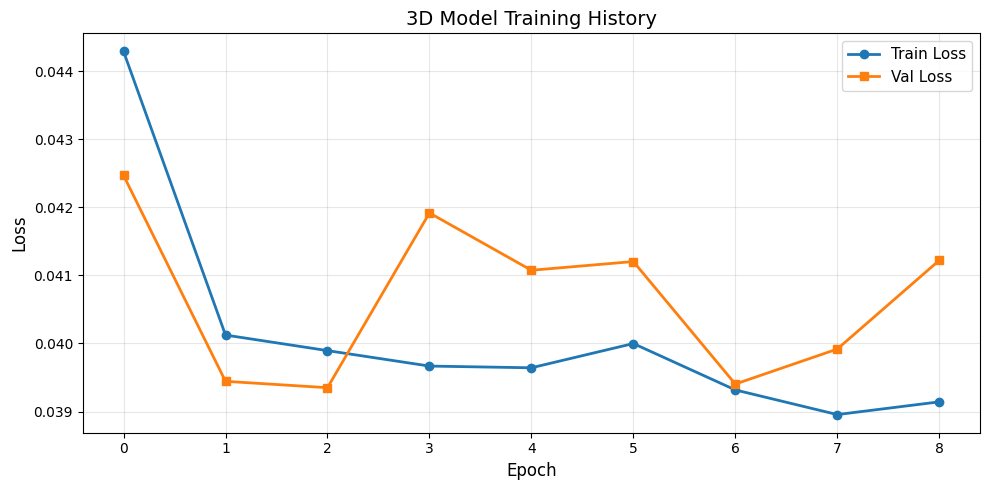

✅ Training history plot saved


In [70]:
# Plot training history
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('3D Model Training History', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'training_history_3d.png'), dpi=100, bbox_inches='tight')
plt.show()

print(f"✅ Training history plot saved")

## 🧪 Section 13: Test Set Evaluation

In [1]:
# Load best model
model.load_state_dict(torch.load(os.path.join(OUTPUT_FOLDER, 'best_model_3d.pth')))

# Test evaluation
model.eval()
all_preds = []
all_probs = []
all_labels = []

print("\n🧪 Evaluating on test set...")
with torch.no_grad():
    for volumes, labels, _ in tqdm(test_loader):
        volumes = volumes.to(device)
        outputs = model(volumes)

        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).int()

        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# Convert to arrays
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# Calculate metrics
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
test_recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
test_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n{'='*70}")
print("📊 TEST SET RESULTS")
print(f"{'='*70}")
print(f"Accuracy:  {test_acc*100:.2f}%")
print(f"Precision: {test_precision*100:.2f}%")
print(f"Recall:    {test_recall*100:.2f}%")
print(f"F1-Score:  {test_f1*100:.2f}%")

NameError: name 'model' is not defined

## 💾 Section 14: Save Results

In [ ]:
# Save final model
torch.save(model.state_dict(), os.path.join(OUTPUT_FOLDER, 'model_3d_final.pth'))

# Save metrics
results = {
    'model': '3D-ResNet18',
    'epochs_trained': len(history['train_loss']),
    'test_accuracy': float(test_acc),
    'test_precision': float(test_precision),
    'test_recall': float(test_recall),
    'test_f1': float(test_f1),
    'timestamp': datetime.now().isoformat(),
    'training_history': {
        'train_loss': [float(x) for x in history['train_loss']],
        'val_loss': [float(x) for x in history['val_loss']]
    }
}

with open(os.path.join(OUTPUT_FOLDER, 'results_3d.json'), 'w') as f:
    json.dump(results, f, indent=4)

print(f"\n{'='*70}")
print("💾 FILES SAVED")
print(f"{'='*70}")
print(f"Model: {os.path.join(OUTPUT_FOLDER, 'model_3d_final.pth')}")
print(f"Results: {os.path.join(OUTPUT_FOLDER, 'results_3d.json')}")
print(f"Plot: {os.path.join(OUTPUT_FOLDER, 'training_history_3d.png')}")